# 1.Dataset Design
inspect missing values, invalid ranges, duplicate sessions, extreme observations, and whether your variables have
sensible relationships

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("developer_productivity.csv")  

In [2]:
df.shape

(400, 13)

the (400,13) shows that the data has 400 rows (entries) and 13 columns. for inspect more and know about the columns and entries, I will use **df.columns** to see the existing all columns in dataset and **df.head()** or also **df.tail()** to inspect some values of the dataset


In [3]:
print(f"Data Cols:{df.columns}\n")

print(f"Some Dataset's data: {df.head()}")

Data Cols:Index(['session_id', 'date', 'day', 'start_hour', 'duration_min',
       'interruptions', 'meeting_overlap', 'caffeine', 'focus', 'energy',
       'tasks_completed', 'bugs_introduced', 'productivity'],
      dtype='object')

Some Dataset's data:   session_id        date        day  start_hour  duration_min  interruptions  \
0       S104  2026-04-01  Wednesday          13            93              2   
1       S381  2026-04-01  Wednesday          13           124              2   
2       S303  2026-04-02   Thursday          18            74              1   
3       S369  2026-04-03     Friday          12            67              0   
4       S272  2026-04-03     Friday          13            59              3   

   meeting_overlap  caffeine  focus  energy  tasks_completed  bugs_introduced  \
0                0       0.0    7.0     6.0                6                1   
1                0       1.0    6.0     5.0                7                1   
2                0  

## Inspect missing values

In [4]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing

,missing_count,missing_percent
session_id,0,0.0
date,0,0.0
day,0,0.0
start_hour,0,0.0
duration_min,0,0.0
interruptions,0,0.0
meeting_overlap,0,0.0
caffeine,6,1.5
focus,6,1.5
energy,6,1.5


In [5]:
df[df["focus"].isna()]

,session_id,date,day,start_hour,duration_min,interruptions,meeting_overlap,caffeine,focus,energy,tasks_completed,bugs_introduced,productivity
8,S138,2026-04-04,Saturday,15,70,2,0,0.0,NaN,4.0,7,0,84.8
17,S150,2026-04-08,Wednesday,9,95,1,0,1.0,NaN,9.0,8,0,91.9
159,S373,2026-05-21,Thursday,13,20,0,0,1.0,NaN,7.0,4,0,76.9
199,S282,2026-05-30,Saturday,10,46,1,0,1.0,NaN,7.0,5,0,94.7
230,S126,2026-06-08,Monday,15,52,2,0,1.0,NaN,10.0,5,2,83.6
258,S123,2026-06-19,Friday,11,85,1,0,1.0,NaN,10.0,9,1,100.0


My observation: They are spread across different dates, days and etc, so there is no  pattern suggesting that the missing values are concentrated in a particular type of session.

In [6]:
df[df["energy"].isna()]

,session_id,date,day,start_hour,duration_min,interruptions,meeting_overlap,caffeine,focus,energy,tasks_completed,bugs_introduced,productivity
88,S363,2026-04-28,Tuesday,17,94,1,0,0.0,6.0,NaN,4,0,92.6
105,S281,2026-05-04,Monday,12,84,3,0,1.0,7.0,NaN,6,1,91.7
109,S314,2026-05-05,Tuesday,11,71,2,0,1.0,7.0,NaN,5,1,73.9
151,S374,2026-05-16,Saturday,16,37,4,1,0.0,6.0,NaN,4,0,55.8
298,S059,2026-06-30,Tuesday,9,83,1,0,1.0,7.0,NaN,8,1,100.0
335,S166,2026-07-09,Thursday,12,53,1,0,1.0,5.0,NaN,3,0,81.3


My observation: it seems that the missing values of the energy is depending on the interruption, so when the energy value is missed, must be at least one intterupt accured during the session. 

In [7]:
df[df["caffeine"].isna()]



,session_id,date,day,start_hour,duration_min,interruptions,meeting_overlap,caffeine,focus,energy,tasks_completed,bugs_introduced,productivity
75,S023,2026-04-23,Thursday,15,36,0,0,NaN,7.0,8.0,5,0,75.7
110,S299,2026-05-05,Tuesday,12,32,0,0,NaN,7.0,3.0,5,2,87.5
111,S399,2026-05-05,Tuesday,20,42,3,0,NaN,6.0,4.0,3,0,56.7
153,S188,2026-05-17,Sunday,18,82,3,0,NaN,5.0,8.0,5,2,71.4
309,S089,2026-07-03,Friday,13,37,0,1,NaN,6.0,8.0,6,2,68.3
353,S232,2026-07-14,Tuesday,16,68,2,0,NaN,10.0,7.0,7,0,82.9


My observation: All of the missed caffeine values is about the sessions have holded in afternoon (or not morning).

## Understand the data types

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   session_id       400 non-null    object 
 1   date             400 non-null    object 
 2   day              400 non-null    object 
 3   start_hour       400 non-null    int64  
 4   duration_min     400 non-null    int64  
 5   interruptions    400 non-null    int64  
 6   meeting_overlap  400 non-null    int64  
 7   caffeine         394 non-null    float64
 8   focus            394 non-null    float64
 9   energy           394 non-null    float64
 10  tasks_completed  400 non-null    int64  
 11  bugs_introduced  400 non-null    int64  
 12  productivity     400 non-null    float64
dtypes: float64(4), int64(6), object(3)
memory usage: 40.8+ KB


In [9]:
#convert date type from object to datetime
df["date"] = pd.to_datetime(df["date"])

#convert caffeine type from float to bool

df["caffeine"] = (
    df["caffeine"]
    .map({1.0: True, 0.0: False})
    .astype("boolean")
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   session_id       400 non-null    object        
 1   date             400 non-null    datetime64[ns]
 2   day              400 non-null    object        
 3   start_hour       400 non-null    int64         
 4   duration_min     400 non-null    int64         
 5   interruptions    400 non-null    int64         
 6   meeting_overlap  400 non-null    int64         
 7   caffeine         394 non-null    boolean       
 8   focus            394 non-null    float64       
 9   energy           394 non-null    float64       
 10  tasks_completed  400 non-null    int64         
 11  bugs_introduced  400 non-null    int64         
 12  productivity     400 non-null    float64       
dtypes: boolean(1), datetime64[ns](1), float64(3), int64(6), object(2)
memory usage: 38.4+ KB


note: replacing float64 to boolean in caffeine value reduced the memory usage.

## Check invalid ranges

| Variable          | Expected range |
| ----------------- | -------------- |
| `start_hour`      | 0–23           |
| `duration_min`    | > 0            |
| `interruptions`   | ≥ 0            |
| `meeting_overlap` | 0 or 1         |
| `caffeine`        | 0 or 1         |
| `focus`           | 1–10           |
| `energy`          | 1–10           |
| `tasks_completed` | ≥ 0            |
| `bugs_introduced` | ≥ 0            |
| `productivity`    | 0–100          |


In [10]:
invalid_valeus = {}

invalid_valeus["start_hour"] = df[(df["start_hour"] > 24) | (df["start_hour"] < 0)]
invalid_valeus["duration_min"] = df[df["duration_min"] < 1]
invalid_valeus["interruptions"] = df[df["interruptions"] < 0]
invalid_valeus["meeting_overlap"] = df[~df["meeting_overlap"].isin([0, 1])]
invalid_valeus["caffeine"] = df[~df["caffeine"].isin([True,False,pd.NA])]
invalid_valeus["focus"] = df[(df["focus"] > 10) | (df["focus"] < 0)]
invalid_valeus["energy"] = df[(df["energy"] > 10) | (df["energy"] < 0)]
invalid_valeus["task_completed"] = df[df["tasks_completed"] < 0]
invalid_valeus["bugs_introduced"] = df[df["bugs_introduced"] < 0]
invalid_valeus["productivity"] = df[(df["productivity"] > 100) | (df["productivity"] < 0)]

invalid_valeus.values



<function dict.values>

As you see there is no invalid value in dataset and all of the values are in the range of each variables

## Use the IQR idea

In [12]:
df.describe()

,start_hour,duration_min,interruptions,meeting_overlap,focus,energy,tasks_completed,bugs_introduced,productivity
count,400.000000,400.000000,400.000000,400.000000,394.000000,394.000000,400.000000,400.000000,400.000000
mean,13.295000,77.977500,1.905000,0.155000,6.642132,6.682741,5.832500,0.682500,76.780250
std,3.075976,23.497816,1.411011,0.362358,1.374560,1.502621,1.626671,0.766919,13.123254
min,8.000000,20.000000,0.000000,0.000000,3.000000,2.000000,1.000000,0.000000,33.600000
25%,11.000000,61.000000,1.000000,0.000000,6.000000,6.000000,5.000000,0.000000,68.000000
50%,13.000000,80.000000,2.000000,0.000000,7.000000,7.000000,6.000000,1.000000,77.700000
75%,16.000000,93.000000,3.000000,0.000000,8.000000,8.000000,7.000000,1.000000,86.225000
max,21.000000,145.000000,8.000000,1.000000,10.000000,10.000000,11.000000,3.000000,100.000000


In [16]:
q1 = df["duration_min"].quantile(0.25)
q3 = df["duration_min"].quantile(0.75)

iqr = q3 - q1

In [20]:
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

outliers = df[
    (df["duration_min"] < lower) |
    (df["duration_min"] > upper)
]

outliers

,session_id,date,day,start_hour,duration_min,interruptions,meeting_overlap,caffeine,focus,energy,tasks_completed,bugs_introduced,productivity
202,S055,2026-05-31,Sunday,11,145,6,0,True,7.0,9.0,8,1,94.7
241,S270,2026-06-12,Friday,13,145,1,0,True,6.0,7.0,7,1,83.1


An IQR outlier is not automatically an error.It means that This observation is unusual relative to the distribution.

# 2.Analize Data and Explore Visually

In [24]:
from matplotlib import pyplot as plt

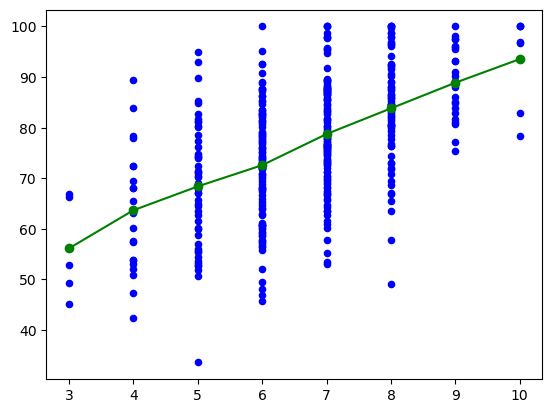

In [ ]:
#the relation between focus and productivity
focus_productivity = df.groupby("focus")["productivity"].mean()

focus_levels = focus_productivity.index.to_numpy()
productivity_means = focus_productivity.values

plt.plot(focus_levels, productivity_means, color="green", marker="o")

fo = df.sort_values(by="focus", ascending=True)
plt.scatter(fo["focus"], fo["productivity"], color="blue", marker="o", s=20)

plt.show()

In [22]:
df.groupby("interruptions")["productivity"].mean()

interruptions
0    82.438095
1    82.014679
2    76.955856
3    72.112500
4    65.971429
5    60.233333
6    70.775000
7    64.300000
8    42.400000
Name: productivity, dtype: float64

In [23]:
df.groupby("start_hour")["productivity"].mean()

start_hour
8     74.218182
9     81.793750
10    81.778846
11    86.604348
12    77.800000
13    68.200000
14    71.217073
15    73.860000
16    71.343243
17    80.203030
18    73.939130
19    79.100000
20    69.133333
21    70.033333
Name: productivity, dtype: float64